<a href="https://colab.research.google.com/github/sonjoy1s/OIBSIP/blob/main/Sales_PredictionTask5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


In [2]:
data = pd.read_csv("/content/Advertising.csv")
df = data

In [3]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.isna().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [5]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [7]:
df['Unnamed: 0'].nunique()

200

In [8]:
df.shape

(200, 5)

In [9]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [10]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


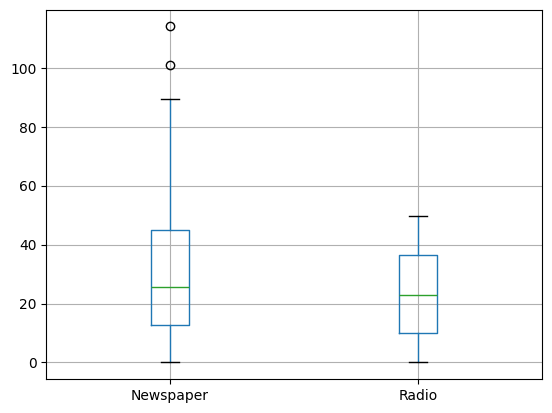

In [14]:
df[['Newspaper','Radio']].boxplot()
plt.show()

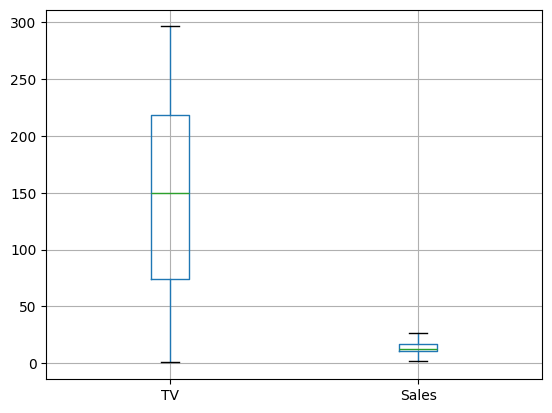

In [15]:
df[['TV','Sales']].boxplot()
plt.show()

/tmp/ipykernel_7980/584260587.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Sales'],bins=50)


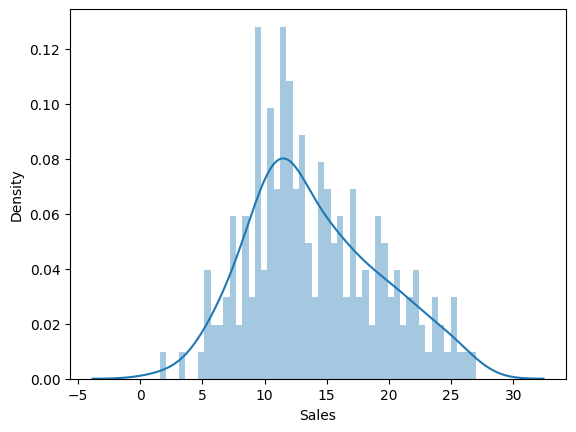

In [17]:
sns.distplot(df['Sales'],bins=50)
plt.show()

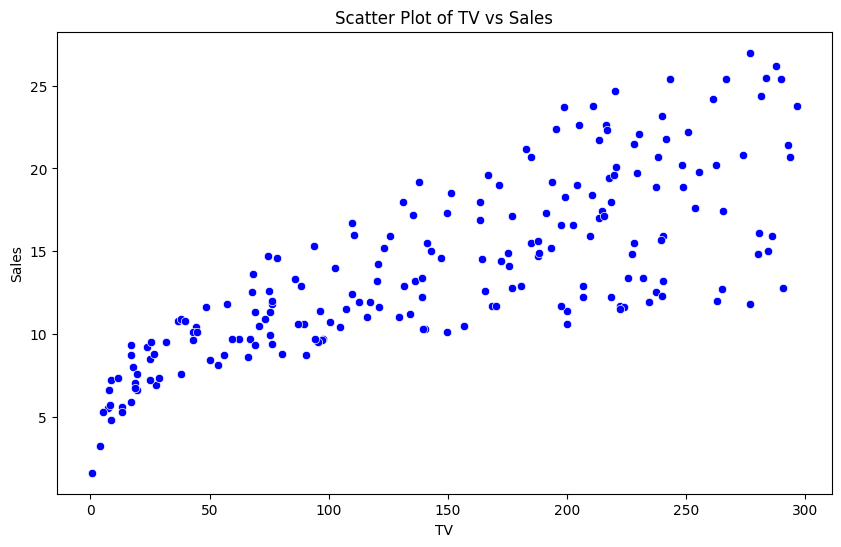

In [18]:
from matplotlib.ticker import ScalarFormatter

# Scatter plot of area vs price using the original dataframe (df)

plt.figure(figsize=(10,6))

sns.scatterplot(x='TV', y='Sales', data=df, color='blue')

plt.title('Scatter Plot of TV vs Sales')

plt.xlabel('TV')
plt.ylabel('Sales')

# Ensure y-axis displays the actual price values without scientific notation

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))  # Disable scientific notation
ax.ticklabel_format(style='plain', axis='y')  # Set plain formatting for y-axis

plt.show()

In [19]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


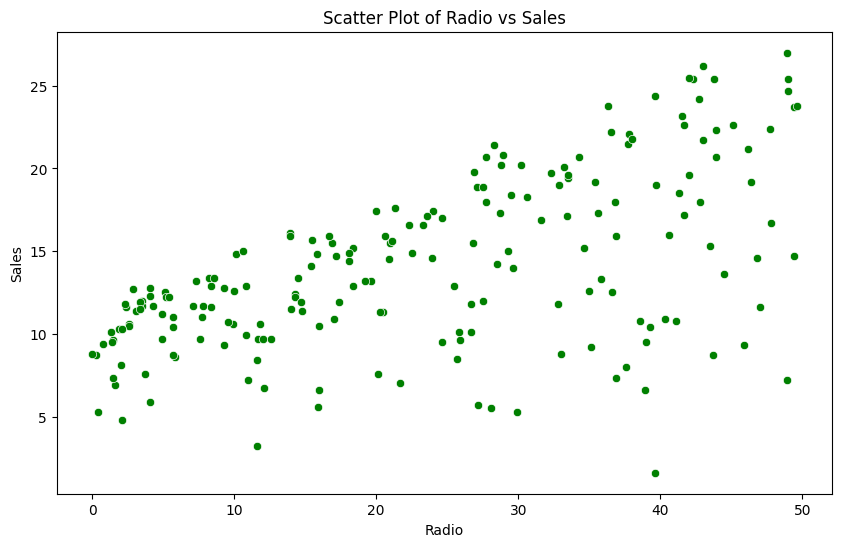

In [21]:
from matplotlib.ticker import ScalarFormatter

# Scatter plot of area vs price using the original dataframe (df)

plt.figure(figsize=(10,6))

sns.scatterplot(x='Radio', y='Sales', data=df, color='Green')

plt.title('Scatter Plot of Radio vs Sales')

plt.xlabel('Radio')
plt.ylabel('Sales')

# Ensure y-axis displays the actual price values without scientific notation

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))  # Disable scientific notation
ax.ticklabel_format(style='plain', axis='y')  # Set plain formatting for y-axis

plt.show()

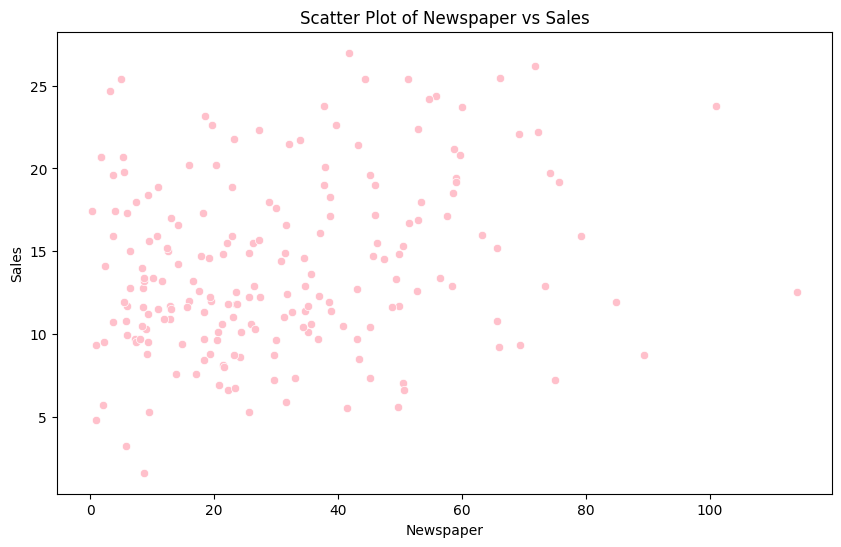

In [26]:
from matplotlib.ticker import ScalarFormatter

# Scatter plot of area vs price using the original dataframe (df)

plt.figure(figsize=(10,6))

sns.scatterplot(x='Newspaper', y='Sales', data=df, color='pink')

plt.title('Scatter Plot of Newspaper vs Sales')

plt.xlabel('Newspaper')
plt.ylabel('Sales')

# Ensure y-axis displays the actual price values without scientific notation

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))  # Disable scientific notation
ax.ticklabel_format(style='plain', axis='y')  # Set plain formatting for y-axis

plt.show()

In [27]:
X = df.drop(columns=['Sales'],axis=1)
y = df['Sales']

In [28]:
numerical_cols  = X.select_dtypes(include=np.number).columns

print(numerical_cols)

categorical_cols = X.select_dtypes(include=object).columns

print(categorical_cols)

Index(['TV', 'Radio', 'Newspaper'], dtype='object')
Index([], dtype='object')


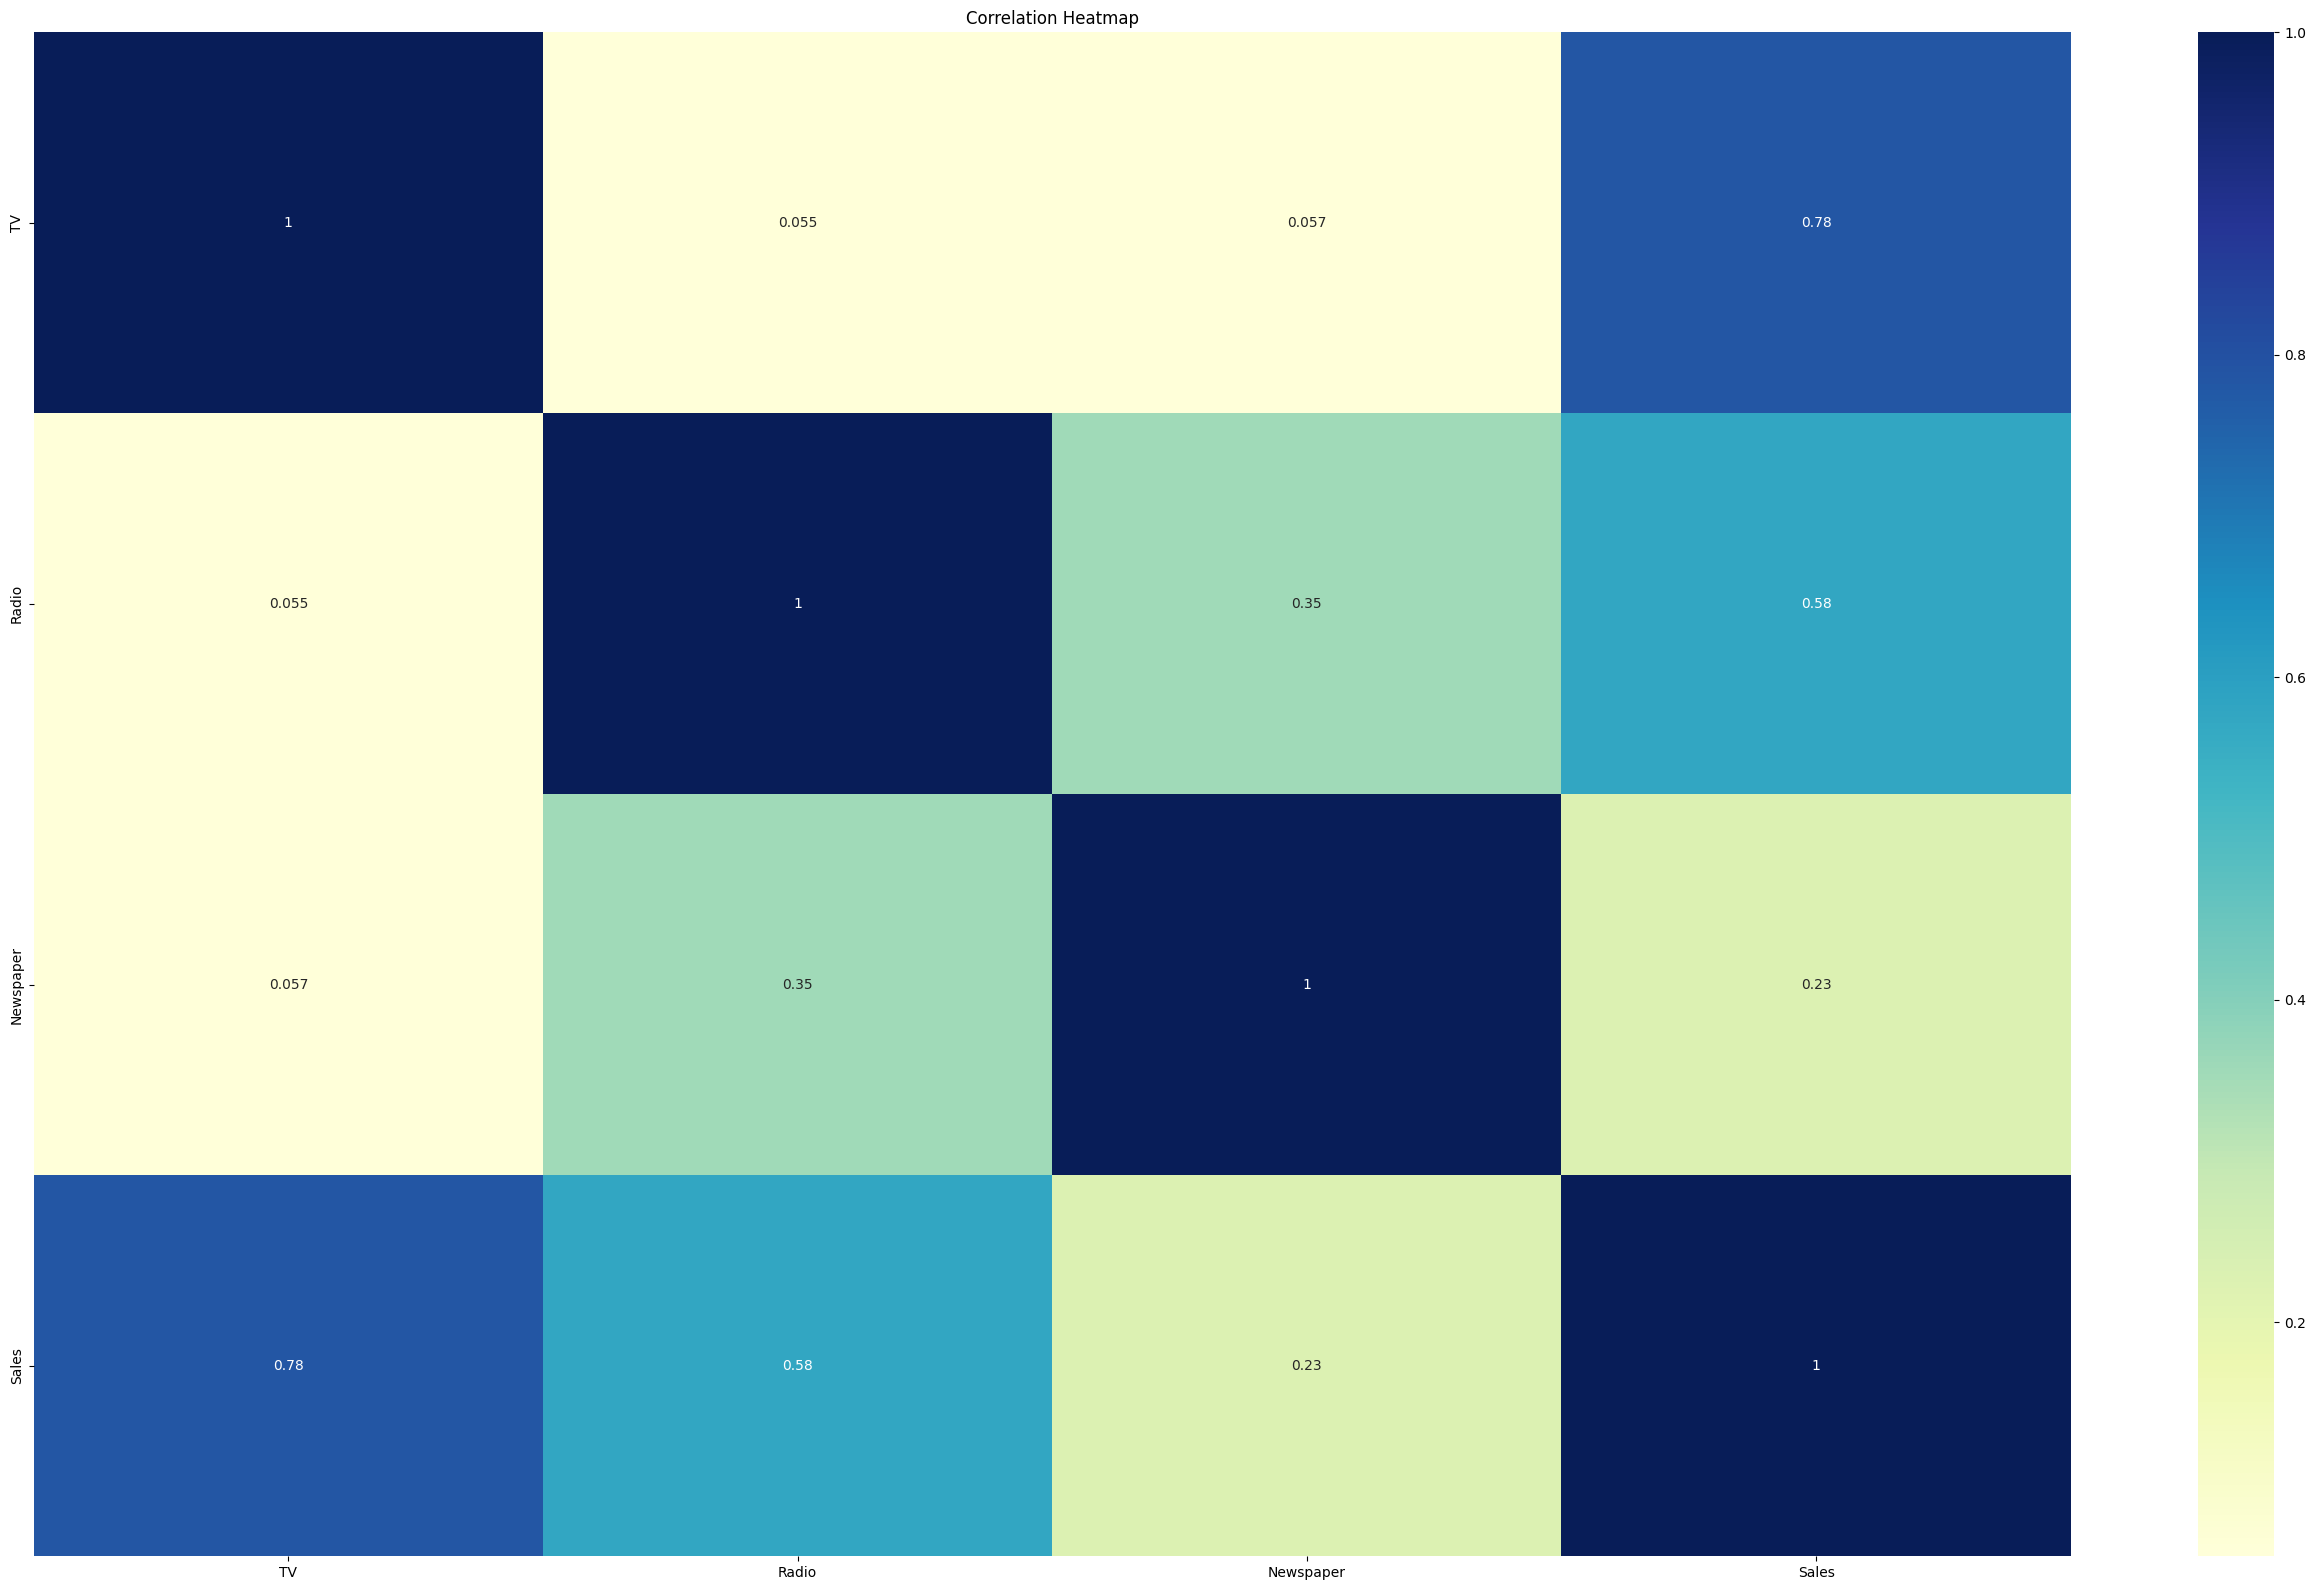

In [31]:
target_col ='Sales'
plt.figure(figsize=(26,16))
corr_matrix = df[list(numerical_cols) + [target_col]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [33]:
#numerical Pipeline
numerical_pipe = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)

In [34]:
categorical_pipe = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehot',OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [35]:
from sklearn.compose import ColumnTransformer
Combine_pipe = ColumnTransformer([
    ('num',numerical_pipe,numerical_cols),
    ('cat',categorical_pipe,categorical_cols)
]
)

In [39]:
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size = 0.25 , random_state=42)

In [60]:
# Base Learner Model
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor,VotingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

linear_reg = LinearRegression() # Use a distinct name for LinearRegression
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()
svr = SVR()
knn = KNeighborsRegressor()
gbr = GradientBoostingRegressor()
abr = AdaBoostRegressor()
linear_svr_model = LinearSVR() # Use a distinct name for LinearSVR

In [61]:
voting_reg = VotingRegressor(
    estimators=[
        ('linear_reg',linear_reg), # Updated to use distinct name
        ('dt',dt),
        ('svr',svr),
        ('rf',rf),
        ('gb',gbr),
        ('linear_svr',linear_svr_model) # Updated to use distinct name

    ]

)

In [62]:
stacking_reg = StackingRegressor(
    estimators=[
        ('linear_reg',linear_reg), # Updated to use distinct name
        ('dt',dt),
        ('svr',svr),
        ('rf',rf),
        ('gb',gbr),
        ('linear_svr',linear_svr_model) # Updated to use distinct name
    ]

)

In [63]:
model_to_train ={
    'LinearRegression':linear_reg, # Updated to use distinct name
    'DecisionTreeRegressor':dt,
    'RandomForestRegressor':rf,
    'SVR':svr,
    'KNeighborsRegressor':knn,
    'GradientBoostingRegressor':gbr,
    'AdaBoostRegressor':abr,
    'LinearSVR':linear_svr_model, # Updated to use distinct name
    'VotingRegressor':voting_reg,
    'StackingRegressor':stacking_reg
}

In [48]:
results = []
for model_name, model in model_to_train.items():
  print(f"--- Training and Evaluating {model_name} ---")
  pipe = Pipeline(
      steps=[
          ('combine', Combine_pipe),
          ('model', model)
      ]
  )
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)

  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  mae = mean_absolute_error(y_test, y_pred)
  results.append({
      'Model':model_name,
      'MSE':mse,
      'R2':r2,
      'MAE':mae
  })
  print(f"MSE: {mse},R2: {r2},MAE : {mae}")

print("\n----All Model Results----")

for result in results:
  print(f"Model: {result['Model']},MSE: {result['MSE']},R2: {result['R2']},MAE: {result['MAE']}")
   # print(f"MSE: {result['MSE']}")
   # print(f"R2: {result['R2']}")
   # print(f"MAE: {result['MAE']}")


--- Training and Evaluating LinearRegression ---
MSE: 2.88002373009419,R2: 0.8935163320163659,MAE : 1.4023124989385065
--- Training and Evaluating DecisionTreeRegressor ---
MSE: 2.383,R2: 0.9118928854115027,MAE : 1.0620000000000003
--- Training and Evaluating RandomForestRegressor ---
MSE: 0.4937587999999999,R2: 0.981744161489434,MAE : 0.5978399999999996
--- Training and Evaluating SVR ---
MSE: 2.251788186387208,R2: 0.9167442048816441,MAE : 1.0091595302385101
--- Training and Evaluating KNeighborsRegressor ---
MSE: 1.8868800000000001,R2: 0.9302360250210895,MAE : 1.0119999999999998
--- Training and Evaluating GradientBoostingRegressor ---
MSE: 0.406229919685449,R2: 0.984980383515316,MAE : 0.5171057928564075
--- Training and Evaluating AdaBoostRegressor ---
MSE: 1.1886727192790472,R2: 0.9560509762963745,MAE : 0.8972304217856032
--- Training and Evaluating LinearSVR ---
MSE: 2.88002373009419,R2: 0.8935163320163659,MAE : 1.4023124989385065
--- Training and Evaluating VotingRegressor ---
MS

In [49]:
best_r2 = -float('inf')
best_model_name = ''

for res in results:
    if res['R2'] > best_r2:
        best_r2 = res['R2']
        best_model_name = res['Model']

best_model_obj = model_to_train[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Best R² Score: {best_r2:.4f}")

Best Model: StackingRegressor
Best R² Score: 0.9859


In [50]:
final_pipe = Pipeline([
    ('combine', Combine_pipe),
    ('model', best_model_obj)
])

final_pipe.fit(X_train, y_train)

y_final_pred = final_pipe.predict(X_test)

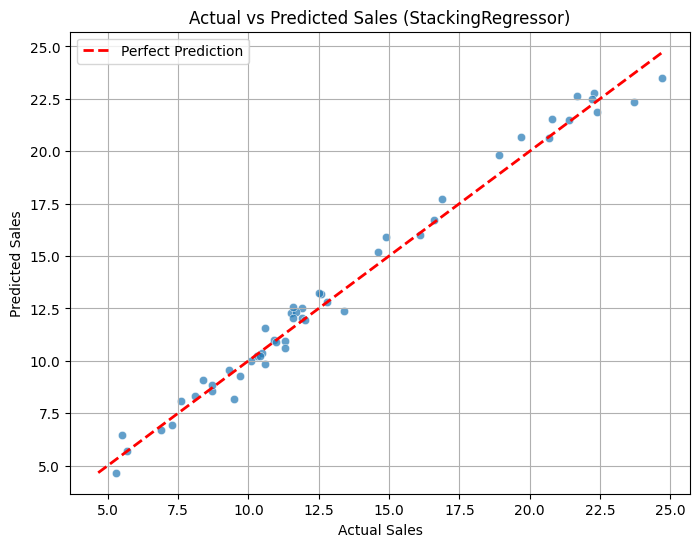

In [52]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_final_pred,
    alpha=0.7
)

min_val = min(min(y_test), min(y_final_pred))
max_val = max(max(y_test), max(y_final_pred))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Actual vs Predicted Sales ({best_model_name})")

plt.legend()
plt.grid(True)

plt.show()

In [53]:
model_reg = stacking_reg
pipe_reg = Pipeline(
    steps=[
        ('combine', Combine_pipe),
        ('model', model_reg)
    ]
)
pipe_reg.fit(X_train, y_train)
y_pred_lr = pipe_reg.predict(X_test)
print(mean_squared_error(y_test, y_pred_lr))
print(r2_score(y_test, y_pred_lr))

0.362346060244801
0.9866029098402521


In [55]:
from sklearn.model_selection import cross_val_score

lg_pipe = Pipeline(
    [
        ('preprocessor', Combine_pipe),
        ('model', stacking_reg)
    ]
)

cross_val = cross_val_score(
    lg_pipe,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("R2 Scores:", cross_val)
print("Mean R2:", cross_val.mean())

R2 Scores: [0.98077653 0.97834786 0.9837865  0.98896893 0.9432898 ]
Mean R2: 0.9750339253914844


In [68]:
print('Re-initializing lg_pipe with updated stacking_reg...')
lg_pipe = Pipeline(
    [
        ('preprocessor', Combine_pipe),
        ('model', stacking_reg)
    ]
)
print('lg_pipe successfully re-initialized.')

Re-initializing lg_pipe with updated stacking_reg...
lg_pipe successfully re-initialized.


In [75]:
param_grid = {

    # SVR tuning
    'model__svr__C': [0.1, 1, 10],
    'model__svr__kernel': ['linear', 'rbf'],

    # Random Forest tuning
    'model__rf__n_estimators': [50,100],
    'model__rf__max_depth': [None,5,10],

    # Gradient Boosting tuning
    'model__gb__n_estimators': [50,100],

    # Linear SVR tuning
    'model__linear_svr__C': [0.01,0.1,1],
    'model__linear_svr__epsilon': [0.1,0.2]
}

In [76]:
print(list(lg_pipe.get_params(deep=True).keys()))

['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'model', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__cat', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__transform_input', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__scaler', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__num__scaler__copy', 'preprocessor__num__scaler__with_mean', 'preprocessor__num__scaler__with_std', 'preprocessor__cat__memory', 'preprocessor__cat__steps', 'prepr

In [77]:
print(stacking_reg)

StackingRegressor(estimators=[('linear_reg', LinearRegression()),
                              ('dt', DecisionTreeRegressor()), ('svr', SVR()),
                              ('rf', RandomForestRegressor()),
                              ('gb', GradientBoostingRegressor()),
                              ('linear_svr', LinearSVR())])


In [78]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=lg_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['TV', 'Radio', 'Newspaper'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unkn...
                                                                       GradientBoostingRegressor()),
                                                                      ('linear_svr',
                                                                       LinearSVR())]))]),
             n_jobs=-1,
             param_grid={'model__gb__n_estimators': [50, 100],
                         'model__linear_svr__C': [0.01, 0.1, 1],
                         'model__linear_svr__epsilon': [0.1, 0.2],
                         'model__rf__max_depth': [None, 5, 10],
                         'model__rf__n_estimators': [50, 100],
                         'model__svr__C': [0.1, 1, 10],
                         'model__svr__kernel': ['linear', 'rbf']},
             scoring='r2', verbose=1)

In [79]:
print("Best Params:")
print(grid_search.best_params_)

print("Best CV R2:")
print(grid_search.best_score_)

Best Params:
{'model__gb__n_estimators': 100, 'model__linear_svr__C': 1, 'model__linear_svr__epsilon': 0.2, 'model__rf__max_depth': 10, 'model__rf__n_estimators': 100, 'model__svr__C': 1, 'model__svr__kernel': 'linear'}
Best CV R2:
0.9768626600933994
